In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu
import statsmodels.stats.power as smp

In [12]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_All_Subjects.xlsx')
df.head()

,Normal Equation,No R_a with Conj,No R_a No Conj
0,20573,15281,24167.0
1,20744,20808,20031.0
2,18912,11858,17489.0
3,20909,24331,21330.0
4,27044,19085,19687.0


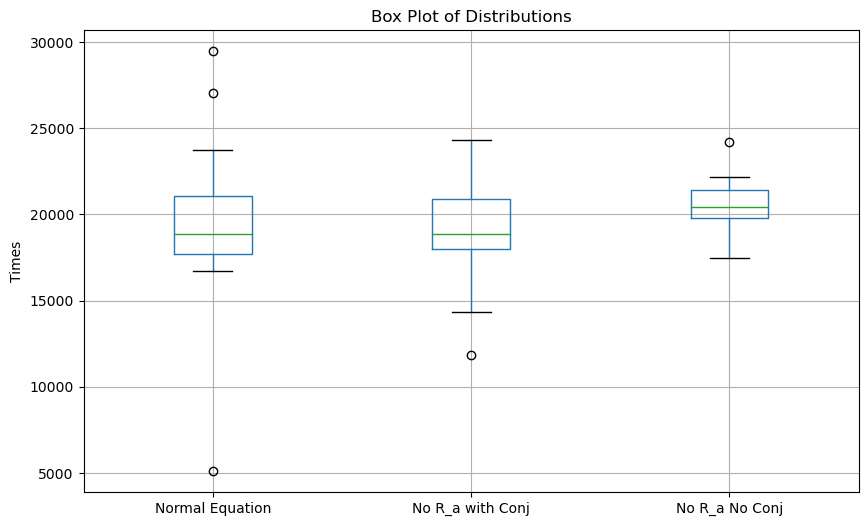

,Mean,Standard Deviation
Normal Equation,19518.30,4788.567406
No R_a with Conj,19037.95,3129.338579
No R_a No Conj,20592.40,1837.434818


In [19]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Times')
plt.show()

# Step 2: Descriptive Statistics
mean_normal = df['Normal Equation'].mean()
std_normal = df['Normal Equation'].std()
mean_no_Ra_w_conjugation = df['No R_a with Conj'].mean()
std_no_Ra_w_conjugation = df['No R_a with Conj'].std()
mean_no_Ra_no_conj = df['No R_a No Conj'].mean()
std_no_Ra_no_conj = df['No R_a No Conj'].std()

descriptive_stats = pd.DataFrame({
    'Mean': [mean_normal, mean_no_Ra_w_conjugation, mean_no_Ra_no_conj],
    'Standard Deviation': [std_normal, std_no_Ra_w_conjugation, std_no_Ra_no_conj]
}, index=['Normal Equation', 'No R_a with Conj', 'No R_a No Conj'])
descriptive_stats

In [ ]:
# Step 3: Statistical Test
t_stat, p_value = ttest_ind(df['Normal Equation'], df.dropna()['No R_a No Conj'])

print(descriptive_stats)
print(f"t-stat = {t_stat}")
print(f"p value = {p_value}")

In [26]:
# Calculate Skewness of a data set.
skew_normal = skew(df['Normal Equation'])
skew_no_ra_no_conj = skew(df['No R_a No Conj'].dropna())

# Step 3: Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Normal Equation'], df['No R_a No Conj'].dropna())

skew_normal, skew_no_ra_no_conj, u_stat, p_value_u

(-0.7637545759696468, 0.27136880449342954, 76.0, 0.30120060673958793)

In [13]:
# Calculate pooled standard deviation
n1 = n2 = df.shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_w_conjugation**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

Power Analysis Inputs:
- Effect size (Cohen's d): Use the effect size estimated from the pilot study.
- Significance level (α): Typically set at 0.05.
- Power (1 - β): Commonly set at 0.80 or 0.90.
- Two-tailed test: If you are interested in differences in both directions.

In [14]:
# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.TTestIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(0.11875320038300669, 1114.0913828900318)

Given the samples provided, the p-value of 0.709 was higher than the alpha and failed to reject the null hypothesis.  Therefore there was no statistical significant difference between the two distributions.  In order to observe a significant difference, a sample size of around 1114 would be needed.  Therefore the response function showed no significant difference in mutant population fixing.  Both samples included bacterial conjugation.

In [4]:
no_ra_no_conj_df = pd.read_excel('Time_for_Bac_Fix_All_Subjects.xlsx', sheet_name='No R_a No Conj')
no_ra_no_conj_df.head()

,Time_s,Time_min,Time_h
0,24167,402.783333,6.713056
1,20031,333.850000,5.564167
2,17489,291.483333,4.858056
3,21330,355.500000,5.925000
4,19687,328.116667,5.468611


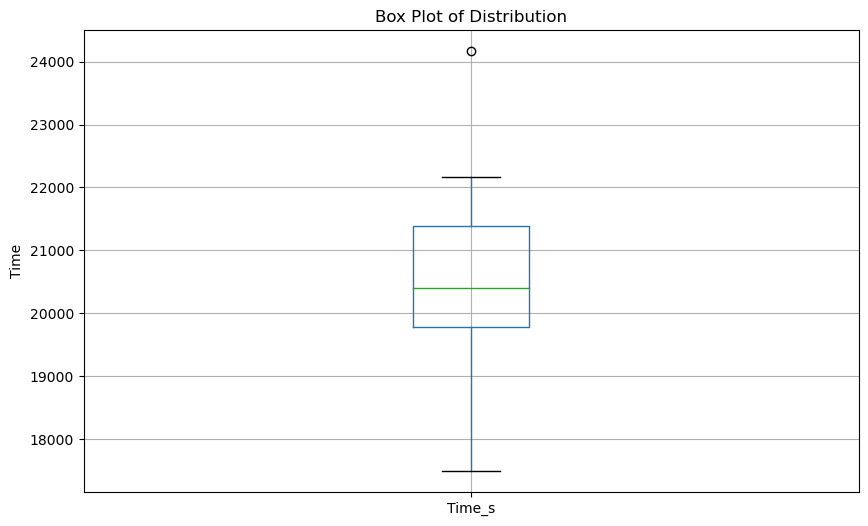

TypeError: ttest_ind() missing 1 required positional argument: 'b'

In [10]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
no_ra_no_conj_df[['Time_s']].boxplot()
plt.title('Box Plot of Distribution')
plt.ylabel('Time')
plt.show()

# Step 2: Descriptive Statistics
mean_no_Ra_no_conj = no_ra_no_conj_df['Time_s'].mean()
std_no_Ra_no_conj = no_ra_no_conj_df['Time_s'].std()

descriptive_stats = pd.DataFrame({
    'Mean': [mean_no_Ra_no_conj],
    'Standard Deviation': [std_no_Ra_no_conj]
}, index=['No R_a No Conjugation'])

# Step 3: Statistical Test
t_stat, p_value = ttest_ind(no_ra_no_conj_df['Time_s'])

print(descriptive_stats)
print(f"t-stat = {t_stat}")
print(f"p value = {p_value}")